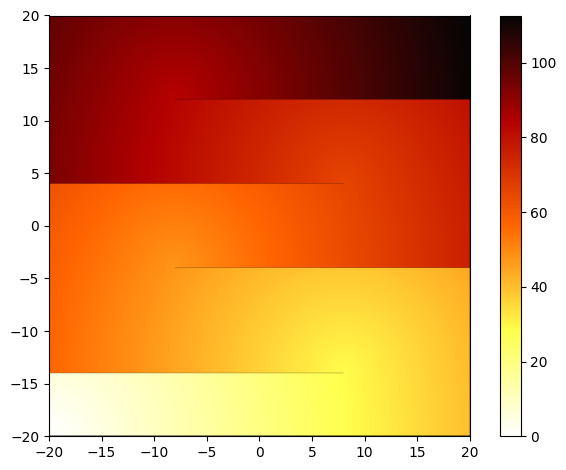

In [ ]:
# ==============================================================================
# VERSIONE FIM JACOBI SENZA LISTA PARALLELIZZATA IN RAWKERNEL SU LABIRINTO 500X500
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

# dominio 500x500
"""
nx = 500
ny = 500
nRows = 500
nCols = 500
sidex = 5
sidey = 5
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 5
"""

# dominio 1000x1000
"""
nx = 1000
ny = 1000
nRows = 1000
nCols = 1000
sidex = 10
sidey = 10
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 5
"""

# dominio 2000x2000

nx = 2000
ny = 2000
nRows = 2000
nCols = 2000
sidex = 20
sidey = 20
domain = [-sidex, sidex, -sidey, sidey]
x = np.linspace(domain[0], domain[1], nx)
y = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
dy = y[1] - y[0]
[X, Y] = np.meshgrid(x, y)
eps = 1e-6

ix0 = 5
iy0 = 5


#------------------  CAMPO DI VELOCITA' (LABIRINTO) ----------------------------
h = dx

F = np.ones(X.shape, dtype=np.float32)

#dominio 500x500

"""
F[:, 1]   = np.inf   # parete sinistra
F[:, 498] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[498, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[99, :]       = np.inf
F[99, 349:498] = 1
# secondo muro orizzontale (riga 200, con apertura a destra)
F[199, :]      = np.inf
F[199, 1:150]  = 1

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 349:498] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:150]  = 1
"""


# dominio 1000x1000
"""
# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 999] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[999, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[199, :]       = np.inf
F[199, 699:999] = 1   # apertura: colonne 350-498 in MATLAB → 349:498 in Python

# secondo muro orizzontale (riga 200, con apertura a destra)
F[399, :]      = np.inf
F[399, 1:299]  = 1   # apertura: colonne 2-150 in MATLAB → 1:150 in Python

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[599, :]       = np.inf
F[599, 699:999] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[799, :]      = np.inf
F[799, 1:299]  = 1
"""

# dominio 2000x2000

# pareti del bordo
F[:, 1]   = np.inf   # parete sinistra
F[:, 1999] = np.inf   # parete destra
F[1, :]   = np.inf   # parete sopra
F[1999, :] = np.inf   # parete sotto

# primo muro orizzontale (riga 100, con apertura a sinistra)
F[299, :]       = np.inf
F[299, 1399:1999] = 1   # apertura: colonne 350-498 in MATLAB → 349:498 in Python

# secondo muro orizzontale (riga 200, con apertura a destra)
F[799, :]      = np.inf
F[799, 1:599]  = 1   # apertura: colonne 2-150 in MATLAB → 1:150 in Python

# terzo muro orizzontale (riga 300, con apertura a sinistra)
F[1199, :]       = np.inf
F[1199, 1399:1999] = 1

# quarto muro orizzontale (riga 400, con apertura a destra)
F[1599, :]      = np.inf
F[1599, 1:599]  = 1


# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

T = np.full(X.shape, 1e30, dtype=np.float32)
T[iy0, ix0] = 0.0

#------------------  UPLOAD CPU -> GPU -----------------------------------------

T_gpu = cp.array(T)
F_gpu = cp.array(F)

#------------------ GODUNOV 1 --------------------------------------------------

godunov_code = godunov_code = r'''
extern "C" __global__
void godunov_update_full(
    const float* T,
    const float* F,
    float*       T_new,
    int          nRows,
    int          nCols,
    float        h
) {

    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= nRows * nCols) return;

    int r = idx / nCols;
    int c = idx % nCols;

    // nodo muro
    float f = F[idx];
    if (isinf(f)) {
        T_new[idx] = 1e30f;
        return;
    }

    // nodo sorgente: non toccare mai
    if (T[idx] == 0.0f) {
        T_new[idx] = 0.0f;
        return;
    }

    float left, right, down, up;

    if (c - 1 < 0 || isinf(F[r * nCols + (c-1)]))
        left = 1e30f;
    else
        left = T[r * nCols + (c-1)];

    if (c + 1 >= nCols || isinf(F[r * nCols + (c+1)]))
        right = 1e30f;
    else
        right = T[r * nCols + (c+1)];

    if (r - 1 < 0 || isinf(F[(r-1) * nCols + c]))
        down = 1e30f;
    else
        down = T[(r-1) * nCols + c];

    if (r + 1 >= nRows || isinf(F[(r+1) * nCols + c]))
        up = 1e30f;
    else
        up = T[(r+1) * nCols + c];

    float Txmin = fminf(left, right);
    float Tymin = fminf(down, up);

    float a = fminf(Txmin, Tymin);
    float b = fmaxf(Txmin, Tymin);

    float rhs = h / f;

    float result;
    if ((b - a) < rhs) {
        float disc = 2.0f * rhs*rhs - (a - b)*(a - b);
        if (disc < 0.0f) disc = 0.0f;
        result = (a + b + sqrtf(disc)) / 2.0f;
    } else {
        result = a + rhs;
    }

    T_new[idx] = result;
}
'''

godunov_ker = cp.RawKernel(godunov_code, 'godunov_update_full')


#------------------  AGGIORNAMENTO FIM JACOBI ----------------------------------

"""
def FIM_senzaLista_raw(T, F):
    threads_per_block = 256
    n = nRows * nCols
    blocchi = (n + threads_per_block - 1) // threads_per_block

    T_new  = cp.empty(n, dtype=cp.float32)
    T_flat = T.ravel().copy()
    F_flat = F.ravel()

    while True:
        p_flat = T_flat.copy()

        godunov_ker(
            (blocchi,), (threads_per_block,),
            (T_flat, F_flat, T_new,
             cp.int32(nRows), cp.int32(nCols), cp.float32(h))
        )

        T_flat = cp.minimum(p_flat, T_new)

        maxdiff = cp.max(cp.abs(p_flat - T_flat))
        if maxdiff < eps:
            break

    return T_flat.reshape(nRows, nCols)
"""
#  versione ottimizzata: controlla ogni 25 passi anzichè ad ogni passo, per
#  allegerire il carico computazionale

def FIM_senzaLista_raw(T, F, check_every=25):
    threads_per_block = 256
    n = nRows * nCols
    blocchi = (n + threads_per_block - 1) // threads_per_block

    # due buffer fissi: eliminano la copy() e l'allocazione ripetuta ad ogni iterazione
    T_a = T.ravel().copy()
    T_b = cp.empty(n, dtype=cp.float32)
    T_new = cp.empty(n, dtype=cp.float32)
    F_flat = F.ravel()

    cur, nxt = T_a, T_b
    it = 0

    while True:
        godunov_ker(
            (blocchi,), (threads_per_block,),
            (cur, F_flat, T_new,
             cp.int32(nRows), cp.int32(nCols), cp.float32(h))
        )

        cp.minimum(cur, T_new, out=nxt)  # scrive direttamente nel buffer esistente

        # il controllo di convergenza (che forza sync GPU->CPU) viene fatto
        # solo ogni check_every iterazioni, non ad ogni passo
        if it % check_every == 0:
            maxdiff = float(cp.max(cp.abs(cur - nxt)))
            if maxdiff < eps:
                cur = nxt
                break

        cur, nxt = nxt, cur
        it += 1

    return cur.reshape(nRows, nCols)

#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM_senzaLista_raw(T_gpu, F_gpu)

# ── torna su CPU per il plot ──────────────────────────────────────────────────
T_final = cp.asnumpy(T_final_gpu)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_SenzaLista_gpu.npz', T_SenzaLista_gpu= T_final)
"""
#------------------  STAMPA DEI RISULTATI --------------------------------------

# maschera i muri (e qualunque cella rimasta a sentinella) prima del plot
T_masked = ma.masked_where(T_final >= 1e29, T_final)

fig, ax = plt.subplots()
im = ax.imshow(T_masked, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
cmap2.set_bad(color='black')   # colore per le celle mascherate (i muri)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()


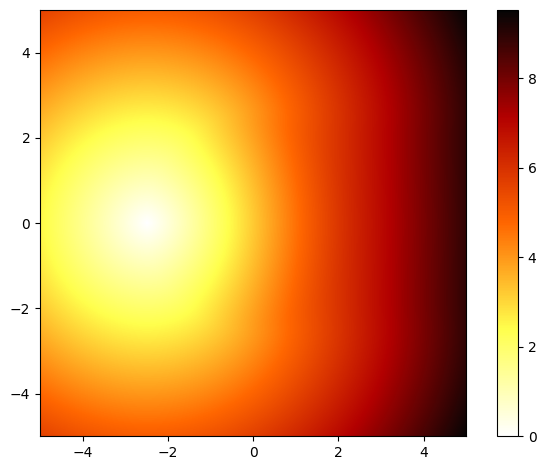

In [ ]:
# ==============================================================================
# VERSIONE FIM JACOBI SENZA LISTA PARALLELIZZATA IN RAWKERNEL SU LENTE LUNEBURG
# ==============================================================================

#------------------  LIBRERIE --------------------------------------------------

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy.interpolate import RegularGridInterpolator
from matplotlib.colors import LinearSegmentedColormap
from google.colab import drive

#------------------  DISCRETIZZAZIONE DEL DOMINIO ------------------------------

nx, ny       = 500, 500
nRows, nCols = 500, 500
sidex, sidey = 5, 5
domain = [-sidex, sidex, -sidey, sidey]
x  = np.linspace(domain[0], domain[1], nx)
y  = np.linspace(domain[2], domain[3], ny)
dx = x[1] - x[0]
X, Y = np.meshgrid(x, y)
eps = 1e-6
h   = dx

ix0 = 5
iy0 = 5

#------------------  CAMPO DI VELOCITA' (LENTE DI LUNEBURG) --------------------
F_oncart = RegularGridInterpolator((X[0, :], Y[:, 0]), np.ones(X.shape).T,
                                    method='linear', bounds_error=False, fill_value=None)

# --- parametri della lente --
R_lens = 2.5        # raggio della lente di Luneburg
xc, yc = 0.0, 0.0   # centro della lente (nell'origine del dominio)
rho = np.sqrt((X - xc)**2 + (Y - yc)**2)
inside = rho < R_lens

n_luneburg = np.ones(X.shape)
n_luneburg[inside] = np.sqrt(2.0 - (rho[inside] / R_lens)**2)

F = np.ones(X.shape)
F = 1.0 / n_luneburg   # F è la VELOCITA', reciproca dell'indice di rifrazione
F[inside] = 1.0 / np.sqrt(2.0 - (rho[inside] / R_lens)**2)

wall_mask = np.isinf(F)


# ==============================================================================
# CALCOLO ICONALE PARALLELIZZATO IN RAWKERNEL
# ==============================================================================

#------------------  SORGENTE --------------------------------------------------

#punto iniziale (sorgente) — nel fuoco, cioè sul bordo della lente
ix0 = np.argmin(np.abs(x - (xc - R_lens)))   # colonna corrispondente a x = xc - R_lens
iy0 = np.argmin(np.abs(y - yc))              # riga corrispondente a y = yc

source_pt = (x[ix0], y[iy0])   # coordinate fisiche della sorgente (il fuoco della lente)

T = np.full(X.shape, np.inf)
T[iy0, ix0] = 0

#------------------  UPLOAD CPU -> GPU -----------------------------------------

F = F.astype(np.float32)
T = T.astype(np.float32)
T_gpu = cp.array(T)
F_gpu = cp.array(F)

#------------------ GODUNOV 1 --------------------------------------------------

godunov_code = godunov_code = r'''
extern "C" __global__
void godunov_update_full(
    const float* T,
    const float* F,
    float*       T_new,
    int          nRows,
    int          nCols,
    float        h
) {

    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx >= nRows * nCols) return;

    int r = idx / nCols;
    int c = idx % nCols;

    // nodo muro
    float f = F[idx];
    if (isinf(f)) {
        T_new[idx] = 1e30f;
        return;
    }

    // nodo sorgente: non toccare mai
    if (T[idx] == 0.0f) {
        T_new[idx] = 0.0f;
        return;
    }

    float left, right, down, up;

    if (c - 1 < 0 || isinf(F[r * nCols + (c-1)]))
        left = 1e30f;
    else
        left = T[r * nCols + (c-1)];

    if (c + 1 >= nCols || isinf(F[r * nCols + (c+1)]))
        right = 1e30f;
    else
        right = T[r * nCols + (c+1)];

    if (r - 1 < 0 || isinf(F[(r-1) * nCols + c]))
        down = 1e30f;
    else
        down = T[(r-1) * nCols + c];

    if (r + 1 >= nRows || isinf(F[(r+1) * nCols + c]))
        up = 1e30f;
    else
        up = T[(r+1) * nCols + c];

    float Txmin = fminf(left, right);
    float Tymin = fminf(down, up);

    float a = fminf(Txmin, Tymin);
    float b = fmaxf(Txmin, Tymin);

    float rhs = h / f;

    float result;
    if ((b - a) < rhs) {
        float disc = 2.0f * rhs*rhs - (a - b)*(a - b);
        if (disc < 0.0f) disc = 0.0f;
        result = (a + b + sqrtf(disc)) / 2.0f;
    } else {
        result = a + rhs;
    }

    T_new[idx] = result;
}
'''

godunov_ker = cp.RawKernel(godunov_code, 'godunov_update_full')


#------------------  AGGIORNAMENTO FIM JACOBI  ---------------------------------

"""
def FIM_senzaLista_raw(T, F):
    threads_per_block = 256
    n = nRows * nCols
    blocchi = (n + threads_per_block - 1) // threads_per_block

    T_new  = cp.empty(n, dtype=cp.float32)
    T_flat = T.ravel().copy()
    F_flat = F.ravel()

    while True:
        p_flat = T_flat.copy()

        godunov_ker(
            (blocchi,), (threads_per_block,),
            (T_flat, F_flat, T_new,
             cp.int32(nRows), cp.int32(nCols), cp.float32(h))
        )

        T_flat = cp.minimum(p_flat, T_new)

        maxdiff = cp.max(cp.abs(p_flat - T_flat))
        if maxdiff < eps:
            break

    return T_flat.reshape(nRows, nCols)
"""
#  versione ottimizzata: controlla ogni 25 passi anzichè ad ogni passo, per
#  allegerire il carico computazionale

def FIM_senzaLista_raw(T, F, check_every=25):
    threads_per_block = 256
    n = nRows * nCols
    blocchi = (n + threads_per_block - 1) // threads_per_block

    # due buffer fissi: eliminano la copy() e l'allocazione ripetuta ad ogni iterazione
    T_a = T.ravel().copy()
    T_b = cp.empty(n, dtype=cp.float32)
    T_new = cp.empty(n, dtype=cp.float32)
    F_flat = F.ravel()

    cur, nxt = T_a, T_b
    it = 0

    while True:
        godunov_ker(
            (blocchi,), (threads_per_block,),
            (cur, F_flat, T_new,
             cp.int32(nRows), cp.int32(nCols), cp.float32(h))
        )

        cp.minimum(cur, T_new, out=nxt)  # scrive direttamente nel buffer esistente

        # il controllo di convergenza (che forza sync GPU->CPU) viene fatto
        # solo ogni check_every iterazioni, non ad ogni passo
        if it % check_every == 0:
            maxdiff = float(cp.max(cp.abs(cur - nxt)))
            if maxdiff < eps:
                cur = nxt
                break

        cur, nxt = nxt, cur
        it += 1

    return cur.reshape(nRows, nCols)

#------------------  SOLVE AND UPLOAD GPU -> CPU -------------------------------

T_final_gpu = FIM_senzaLista_raw(T_gpu, F_gpu)

# ── torna su CPU per il plot ──────────────────────────────────────────────────
T_final = cp.asnumpy(T_final_gpu)

#------------------  SALVATAGGIO IN DRIVE --------------------------------------

"""
drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/Colab Notebooks/Risultati/'


np.savez(save_path + 'T_SenzaLista_gpu.npz', T_SenzaLista_gpu= T_final)
"""
#------------------  STAMPA DEI RISULTATI --------------------------------------

# maschera i muri (e qualunque cella rimasta a sentinella) prima del plot
T_masked = ma.masked_where(T_final >= 1e29, T_final)

fig, ax = plt.subplots()
im = ax.imshow(T_masked, extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
plt.colorbar(im, ax=ax)

stops = np.array([
    [1.00, 1.00, 1.00],
    [1.00, 1.00, 0.30],
    [1.00, 0.40, 0.00],
    [0.70, 0.00, 0.00],
    [0.02, 0.02, 0.02],
])
cmap2 = LinearSegmentedColormap.from_list("custom", stops, N=256)
cmap2.set_bad(color='black')   # colore per le celle mascherate (i muri)
im.set_cmap(cmap2)
plt.tight_layout()
plt.show()
